### Check results of mapping

In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from collections import Counter
from pathlib import Path

In [2]:
BASE_DIR = Path(".").resolve()

while BASE_DIR != BASE_DIR.parent:
    if (BASE_DIR / "data").exists() and (BASE_DIR / "docs").exists():
        break
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = DATA_DIR / "mapping_data"
DOCS_DIR = BASE_DIR / "docs"

train_labels_dir = OUTPUT_DIR / "train" / "labels"
train_images_dir = OUTPUT_DIR / "train" / "images"

print("Проверка путей:")
print(f"BASE_DIR: {BASE_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"OUTPUT_DIR существует: {OUTPUT_DIR.exists()}")
print(f"train_images_dir: {train_images_dir}")
print(f"train_images_dir существует: {train_images_dir.exists()}")

if train_images_dir.exists():
    img_count = len(list(train_images_dir.glob("*.jpg")))
    print(f"Найдено изображений: {img_count}")
else:
    print("ОШИБКА: Папка train/images не найдена!")
    print("Запусти сначала data_to_belarus.ipynb для создания датасета")

Проверка путей:
BASE_DIR: /home/ruslana/Projects/RaspberryYolo/RaspberryRoadSign
OUTPUT_DIR: /home/ruslana/Projects/RaspberryYolo/RaspberryRoadSign/data/mapping_data
OUTPUT_DIR существует: True
train_images_dir: /home/ruslana/Projects/RaspberryYolo/RaspberryRoadSign/data/mapping_data/train/images
train_images_dir существует: True
Найдено изображений: 1330


In [3]:
class_counts = Counter()
class_examples = {} 

print("🔍 Сканируем текстовые аннотации в train...")
for label_file in train_labels_dir.glob("*.txt"):
    img_file = train_images_dir / (label_file.stem + ".jpg")
    if not img_file.exists():
        continue
        
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            
            cls_id = int(parts[0])
            class_counts[cls_id] += 1
            
            # Сохраняем пример рамки для визуальной галереи
            if cls_id not in class_examples:
                class_examples[cls_id] = (img_file, [float(x) for x in parts[1:]])

print(f"✓ Сканирование завершено. Рамок обработано: {sum(class_counts.values())}")

🔍 Сканируем текстовые аннотации в train...
✓ Сканирование завершено. Рамок обработано: 1545


In [4]:
NAMES_DICT_103 = {
    0: '2.1: Главная дорога', 1: '1.21: Дети', 2: '1.16.1: Искусственная неровность',
    3: '3.24: Ограничение максимальной скорости', 4: '5.16: Пешеходный переход',
    5: '5.12.1: Остановочный пункт автобуса', 6: '3.25: Конец зоны ограничения скорости',
    7: '5.33: Стоп-линия', 8: '2.2: Конец главной дороги', 9: '2.4: Уступить дорогу',
    10: '4.2.1: Объезд препятствия справа', 11: '1.23: Дорожные работы',
    12: '3.4: Движение грузовых ТС запрещено', 13: '4.1.6: Движение направо или налево',
    14: '4.2.3: Объезд препятствия справа или слева', 15: '4.1.1: Движение прямо',
    16: '1.30: Прочие опасности', 17: '3.27: Остановка запрещена', 18: '1.15: Скользкая дорога',
    19: '5.11.1: Место для разворота', 20: '5.17.3-4: Надземный пешеходный переход',
    21: '6.3: Автозаправочная станция', 22: '1.32: Опасная обочина', 23: '5.15: Место стоянки',
    24: '1.16.2-4: Неровная дорога', 25: '1.11.2: Опасный поворот (налево)',
    26: '5.17.1-2: Подземный пешеходный переход', 27: '6.2: Больница',
    28: '3.18.1: Поворот направо запрещён', 29: '5.6: Конец дороги с односторонним движением',
    30: '5.5: Дорога с односторонним движением', 31: '6.4: Техническое обслуживание автомобилей',
    32: '4.1.2: Движение направо', 33: '6.11: Место отдыха', 34: '1.20: Впереди пешеходный переход',
    35: '1.25: Дикие животные', 36: '2.3.2: Примыкание второстепенной дороги (справа)',
    37: '1.8: Светофорное регулирование', 38: '3.13: Ограничение высоты',
    39: '2.3.1: Пересечение со второстепенной дорогой', 40: '2.3.3: Примыкание второстепенной дороги (слева)',
    41: '6.7: Пункт питания', 42: '1.11.1: Опасный поворот (направо)',
    43: '1.12.2: Опасные повороты (первый — налево)', 44: '1.18.1: Сужение дороги с обеих сторон',
    45: '1.12.1: Опасные повороты (первый — направо)', 46: '3.32: Движение ТС с опасными грузами запрещено',
    47: '2.5: Движение без остановки запрещено', 48: '3.1: Въезд запрещён',
    49: '3.20: Обгон запрещён', 50: '3.2: Движение запрещено', 51: '5.39: Конец жилой зоны',
    52: '5.14.2: Место стоянки такси', 53: '6.5: Мойка автомобилей', 54: '3.14: Ограничение ширины',
    55: '1.2: Железнодорожный переезд без шлагбаума', 56: '4.1.4: Движение прямо или направо',
    57: '6.6: Телефон', 58: '4.3: Круговое движение', 59: '4.1.5: Движение прямо или налево',
    60: '3.10: Движение пешеходов запрещено', 61: '4.2.2: Объезд препятствия слева',
    62: '6.1: Пункт первой медицинской помощи', 63: '3.28: Стоянка запрещена', 64: '4.1.3: Движение налево',
    65: '5.4: Конец дороги для автомобилей', 66: '5.3: Дорога для автомобилей',
    67: '3.31: Конец зоны всех ограничений', 68: '5.18.1: Рекомендуемая скорость',
    69: '1.19: Двустороннее движение', 70: '3.21: Конец зоны запрещения обгона',
    71: '1.13: Крутой спуск', 72: '1.14: Крутой подъём', 73: '2.3.4: Пересечение равнозначных дорог',
    74: '2.6: Преимущество встречного движения', 75: '3.18.2: Поворот налево запрещён',
    76: '1.7: Пересечение с круговым движением', 77: '3.19: Разворот запрещён', 78: '1.17: Выброс щебня',
    79: '2.7: Преимущество перед встречным движением', 80: '5.9.1: Полоса для маршрутных ТС',
    81: '5.38: Жилая зона', 82: '1.1: Железнодорожный переезд со шлагбаумом', 83: '4.5.1: Пешеходная дорожка',
    84: '3.11: Ограничение массы', 85: '3.30: Стоянка запрещена по чётным числам',
    86: '5.7.1: Выезд на дорогу с односторонним движением', 87: '5.7.2: Выезд на дорогу с односторонним движением',
    88: '1.5: Пересечение with трамвайной линией', 89: '3.29: Стоянка запрещена по нечётным числам',
    90: '5.10.4: Конец дороги с полосой для маршрутных ТС', 91: '3.16: Ограничение минимальной дистанции',
    92: '1.28: Низколетящие самолеты', 93: '5.10.1: Дорога с полосой для маршрутных ТС',
    94: '3.12: Ограничение нагрузки на ось', 95: '3.33: Зона с ограничением максимальной скорости',
    96: '5.35: Реверсивное движение', 97: '3.6: Движение тракторов запрещено', 98: '1.24: Перегон скота',
    99: '5.13.1: Остановочный пункт трамвая', 100: '1.10: Выезд на набережную', 101: '6.13: Туалет',
    102: '6.14: Пункт контроля автомобильных перевозок'
}

stats_data = []
for model_id in range(103):
    stats_data.append({
        "ID": model_id,
        "Название": NAMES_DICT_103[model_id],
        "Количество": class_counts.get(model_id, 0)
    })

df_stats = pd.DataFrame(stats_data)
weakest = df_stats.sort_values(by="Количество").head(15)

print("🚨 ТОП-15 САМЫХ РЕДКИХ КЛАССОВ (Требуют искусственного расширения):")
print("==================================================================")
print(weakest.to_string(index=False))

🚨 ТОП-15 САМЫХ РЕДКИХ КЛАССОВ (Требуют искусственного расширения):
 ID                                   Название  Количество
  0                        2.1: Главная дорога          15
  1                                 1.21: Дети          15
  2           1.16.1: Искусственная неровность          15
  3    3.24: Ограничение максимальной скорости          15
  4                   5.16: Пешеходный переход          15
  5        5.12.1: Остановочный пункт автобуса          15
  6      3.25: Конец зоны ограничения скорости          15
  7                           5.33: Стоп-линия          15
  8                  2.2: Конец главной дороги          15
  9                       2.4: Уступить дорогу          15
 10           4.2.1: Объезд препятствия справа          15
 11                      1.23: Дорожные работы          15
 12        3.4: Движение грузовых ТС запрещено          15
 13         4.1.6: Движение направо или налево          15
 14 4.2.3: Объезд препятствия справа или слева  

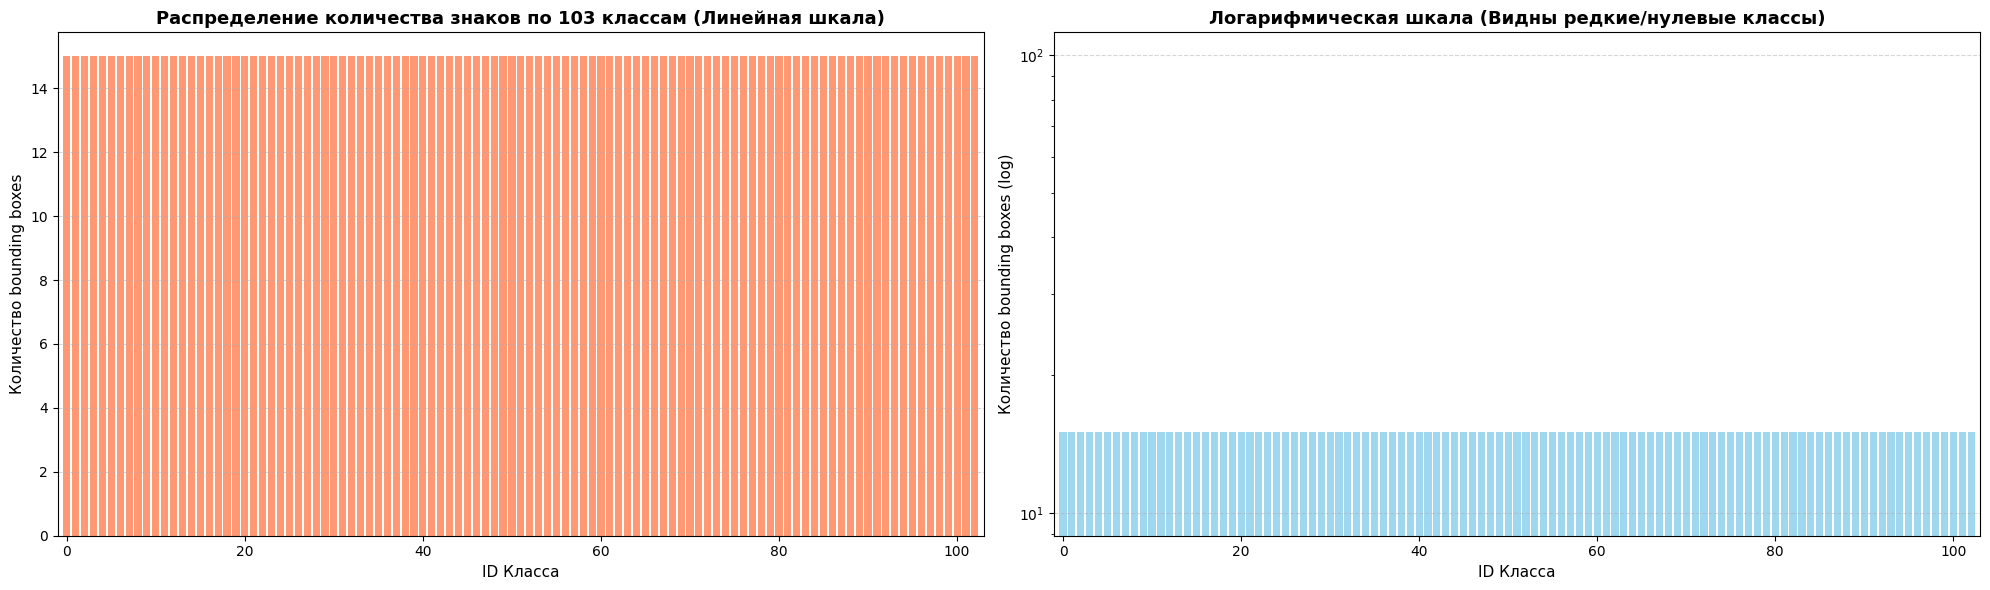

In [5]:
plt.figure(figsize=(20, 6))

# Левый график (Линейная шкала)
plt.subplot(1, 2, 1)
colors = ['red' if x == 0 else 'coral' for x in df_stats["Количество"]]
plt.bar(df_stats["ID"], df_stats["Количество"], color=colors, alpha=0.8)
plt.title("Распределение количества знаков по 103 классам (Линейная шкала)", fontsize=13, fontweight='bold')
plt.xlabel("ID Класса", fontsize=11)
plt.ylabel("Количество bounding boxes", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(-1, 103)

# Правый график (Логарифмическая шкала для редких классов)
plt.subplot(1, 2, 2)
y_values = [max(x, 1) for x in df_stats["Количество"]]  
colors2 = ['red' if x == 0 else 'skyblue' for x in df_stats["Количество"]]
plt.bar(df_stats["ID"], y_values, color=colors2, alpha=0.8)
plt.yscale('log')
plt.title("Логарифмическая шкала (Видны редкие/нулевые классы)", fontsize=13, fontweight='bold')
plt.xlabel("ID Класса", fontsize=11)
plt.ylabel("Количество bounding boxes (log)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(-1, 103)

plt.tight_layout()
plt.show()  # Вызываем show() один раз строго в самом конце ячейки!

🖼️ Начинаем отрисовку кроп-галереи для визуальной проверки маппинга...


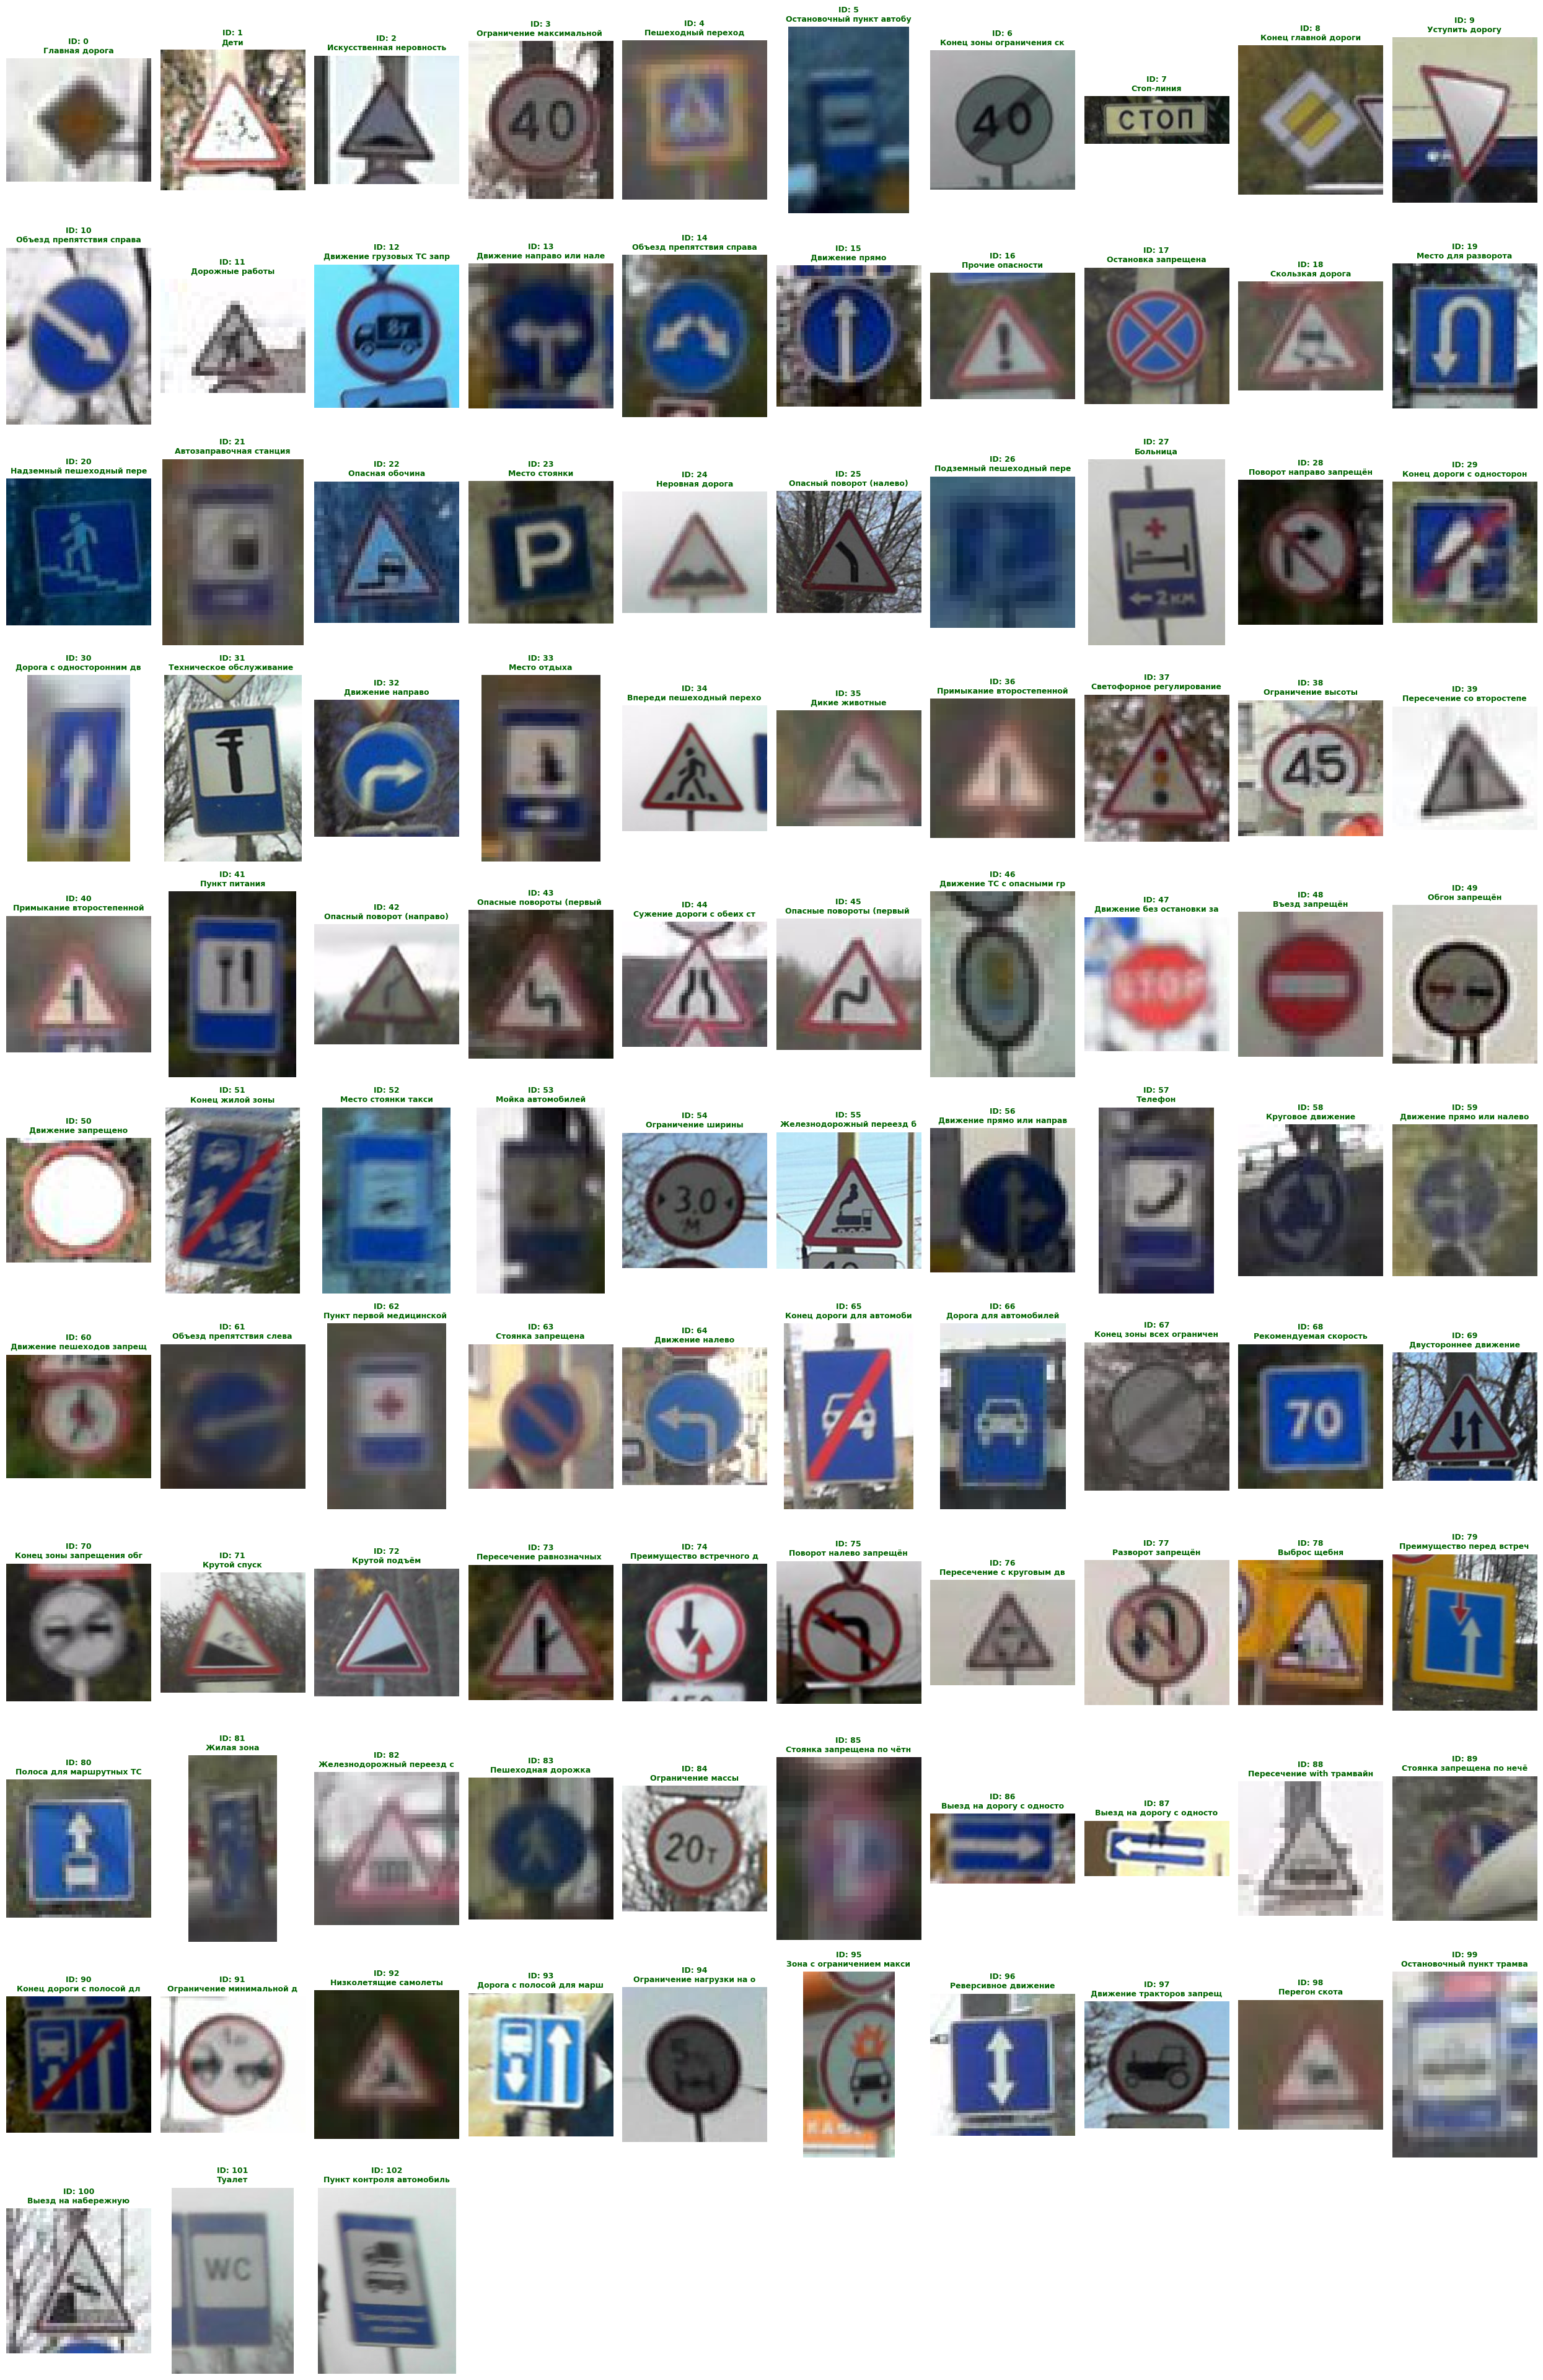

In [6]:
print("🖼️ Начинаем отрисовку кроп-галереи для визуальной проверки маппинга...")
cols = 10
rows = math.ceil(103 / cols)
fig, axes = plt.subplots(rows, cols, figsize=(25, rows * 3.5))
axes = axes.flatten()

for model_id in range(103):
    ax = axes[model_id]
    ax.axis("off")  
    
    # Извлекаем только текстовую часть названия знака для подписи
    clean_name = NAMES_DICT_103[model_id].split(': ')[-1][:25]
    title_text = f"ID: {model_id}\n{clean_name}"
    
    if model_id in class_examples:
        img_path, bbox = class_examples[model_id]
        try:
            img = Image.open(img_path)
            img_w, img_h = img.size
            xc, yc, w, h = bbox
            
            # Пересчитываем нормализованные YOLO координаты в пиксели
            left = (xc - w / 2) * img_w
            right = (xc + w / 2) * img_w
            top = (yc - h / 2) * img_h
            bottom = (yc + h / 2) * img_h
            
            # Контекстный padding в 20%
            pad_x = (right - left) * 0.2
            pad_y = (bottom - top) * 0.2
            
            left = max(0, left - pad_x)
            right = min(img_w, right + pad_x)
            top = max(0, top - pad_y)
            bottom = min(img_h, bottom + pad_y)
            
            sign_crop = img.crop((left, top, right, bottom))
            
            ax.imshow(sign_crop)
            ax.set_title(title_text, fontsize=9, color="darkgreen", fontweight="bold")
        except Exception as e:
            ax.set_title(f"{title_text}\n(Ошибка)", fontsize=9, color="red")
    else:
        ax.set_title(f"{title_text}\n(НЕТ ДАННЫХ)", fontsize=9, color="red")

for i in range(103, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# ЯЧЕЙКА: КОМПЛЕКСНЫЙ АУДИТ МОДЕЛИ И ДАТАСЕТА С СОХРАНЕНИЕМ В CSV / JSON
# ==============================================================================
import os
import json
import pandas as pd
from ultralytics import YOLO

# 1. Укажи актуальный путь к файлу весов твоей модели
PATH_TO_MODEL = BASE_DIR / "models/best.pt"  # или "models/best.pt"

# Автоматически собираем железобетонный абсолютный путь к data.yaml
yaml_path = str((OUTPUT_DIR / "data.yaml").resolve())

if not os.path.exists(PATH_TO_MODEL):
    print(f"❌ Файл весов не найден по пути: {PATH_TO_MODEL}")
elif not os.path.exists(yaml_path):
    print(f"❌ Конфигурация data.yaml не найдена по пути: {yaml_path}")
    print("👉 Сначала запусти ноутбук конвертации 'data_to_belarus.ipynb'!")
else:
    print(f"📦 Загружаем модель: {PATH_TO_MODEL} ...")
    model = YOLO(PATH_TO_MODEL)
    model_classes = model.names
    
    # 2. Запускаем тест модели на валидационной выборке
    print("\n⚡ Запускаем валидацию модели на датасете...")
    metrics = model.val(
        data=yaml_path, 
        imgsz=640, 
        batch=16, 
        device=0, 
        plots=False
    )
    
    # 3. Собираем точность (mAP50) для каждого из 103 классов
    print("\n📊 Извлекаем метрики точности по классам...")
    performance_rows = []
    for class_id, class_name in model_classes.items():
        try:
            # Извлекаем mAP50 (индекс 2 в результатах класса библиотеки Ultralytics)
            class_map50 = metrics.class_result(class_id)[2]
        except:
            class_map50 = 0.0  # если класс отсутствовал на валидации
            
        performance_rows.append({
            "ID": int(class_id),
            "Точность (mAP50)": round(float(class_map50), 4)
        })
    df_perf = pd.DataFrame(performance_rows)
    
    # 4. СЛИЯНИЕ ДАННЫХ: Объединяем количество картинок из Train и точность модели!
    if 'df_stats' in locals() or 'df_stats' in globals():
        print("🔗 Интегрируем точность модели со статистикой объемов датасета...")
        # df_stats был создан в Ячейке 3 (содержит ID, Название, Количество)
        df_full_analysis = pd.merge(df_stats, df_perf, on="ID", how="left")
    else:
        print("⚠️ Предупреждение: df_stats не найден в памяти. Сохраняем только метрики модели.")
        df_full_analysis = df_perf
        # Добавляем текстовые имена из нашего эталонного NAMES_DICT_103 для автономии
        df_full_analysis["Название"] = df_full_analysis["ID"].map(NAMES_DICT_103)
    
    # Сортируем таблицу строго по порядку ID (от 0 до 102)
    df_full_analysis = df_full_analysis.sort_values(by="ID").reset_index(drop=True)
    
    # 5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ НА ДИСК
    docs_dir = BASE_DIR / "docs"
    docs_dir.mkdir(parents=True, exist_ok=True)
    
    csv_output_path = docs_dir / "full_model_and_dataset_analysis.csv"
    json_output_path = docs_dir / "full_model_and_dataset_analysis.json"
    
    # utf-8-sig гарантирует, что Excel сразу откроет кириллицу красиво и без кракозябр
    df_full_analysis.to_csv(csv_output_path, index=False, encoding="utf-8-sig")
    df_full_analysis.to_json(json_output_path, orient="records", force_ascii=False, indent=4)
    
    print(f"\n💾 АНАЛИТИКА УСПЕШНО ЗАПИСАНА НА ДИСК!")
    print(f"  🟢 Таблица для Excel (CSV): {csv_output_path.resolve()}")
    print(f"    [Колонки: ID, Название, Количество в Train, Точность (mAP50)]")
    print(f"  🟢 Файл структуры JSON:   {json_output_path.resolve()}")
    
    # Выводим небольшое превью топ-10 худших мест для быстрой сверки
    print("\n📋 Краткое превью топ-10 слабых классов:")
    print(df_full_analysis.sort_values(by="Точность (mAP50)").head(10).to_string(index=False))

📦 Загружаем модель: /home/ruslana/Projects/RaspberryYolo/RaspberryRoadSign/models/best.pt ...

⚡ Запускаем валидацию модели на датасете...
Ultralytics 8.3.232 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
YOLO11n summary (fused): 101 layers, 2,648,497 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3903.4±1917.5 MB/s, size: 188.6 KB)
val: Scanning /home/ruslana/Projects/RaspberryYolo/RaspberryRoadSign/data/mapping_data/val/labels.cache... 4516 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4516/4516 9.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 283/283 12.2it/s 23.1s<0.1s
                   all       4516       7303      0.594      0.519      0.578       0.42
   2.1: Главная дорога        929        934      0.885      0.954      0.966      0.707
            1.21: Дети        225        229      0.619      0.817      0.786    

НЕСОСТЫКОВКИ:
- ID 4
- ID 5
- ID 7
- ID 14
- ID 38
- ID 43
- ID 45
- ID 73
- ID 74
- ID 83
- 

- ПРОВЕРИТЬ А КАК В МОДЕЛЕ ЭТО ВСЕ СДЕЛАНО
- ДОБАВИТЬ ЕЩЕ КЛАССЫ СОГЛАСНО КАРТИНКАМ И ЗНАКАМ
